In [1]:
from pathlib import Path
from typing import Tuple

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, signal

from tqdm import tqdm
import math

# np.set_printoptions(precision=4)

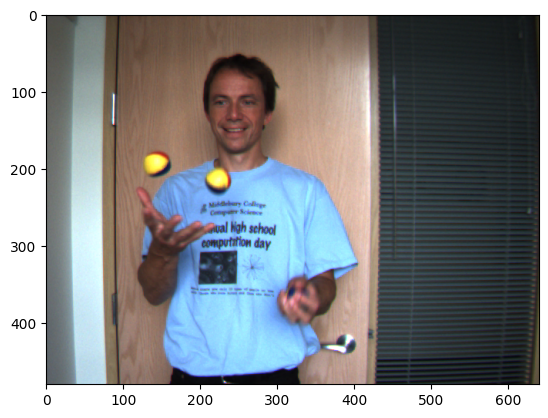

In [33]:
input_dir = Path('ps5_python/Juggle')
shift_0 = cv.imread(str(input_dir / '0.png'))
img = cv.cvtColor(shift_0, cv.COLOR_BGR2RGB)
plt.imshow(img)

In [41]:
def show_channels(img):
    img_R = img[:,:,0]
    img_G = img[:,:,1]
    img_B = img[:,:,2]
    plt.figure(figsize=(15,10))
    plt.subplot(131)
    plt.title("Red channel")
    plt.imshow(img_R, cmap="gray")

    plt.subplot(132)
    plt.title("Green channel")
    plt.imshow(img_G, cmap="gray")

    plt.subplot(133)
    plt.title("Blue channel")
    plt.imshow(img_B, cmap="gray")

    plt.show()

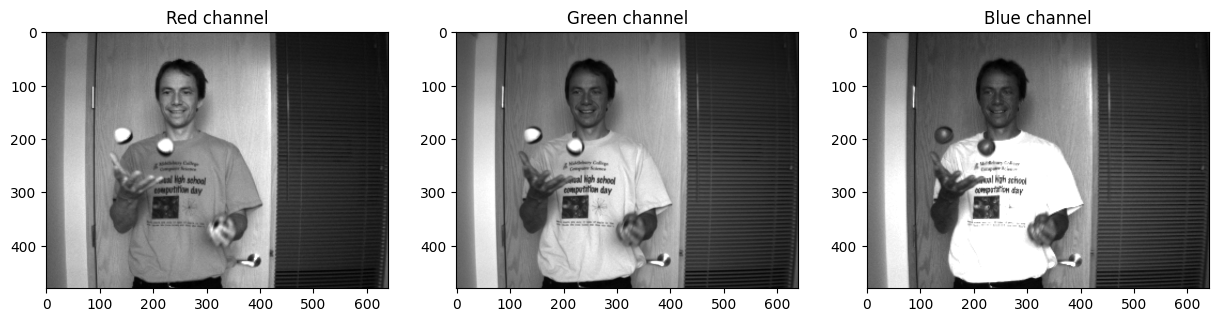

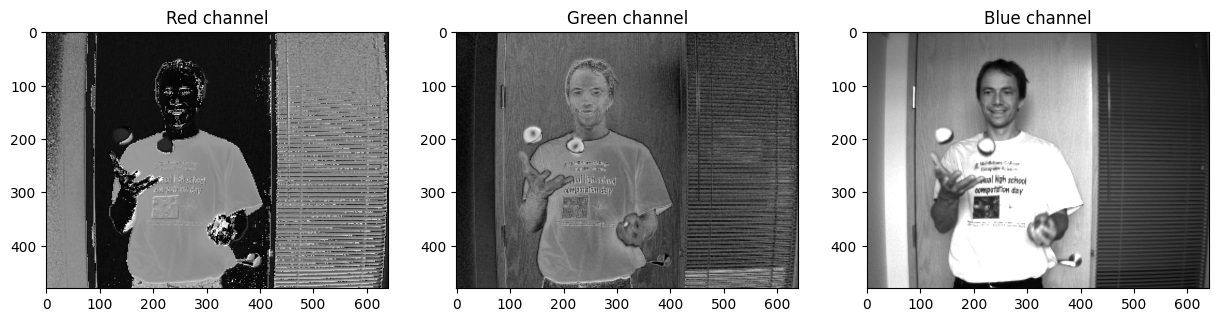

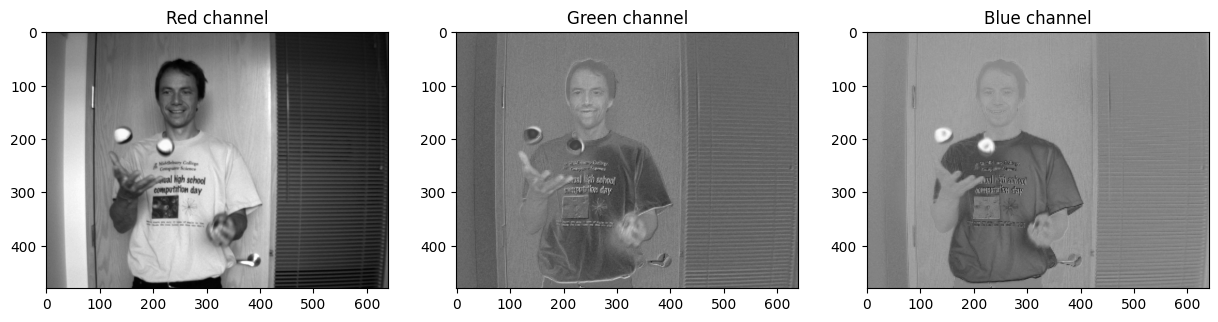

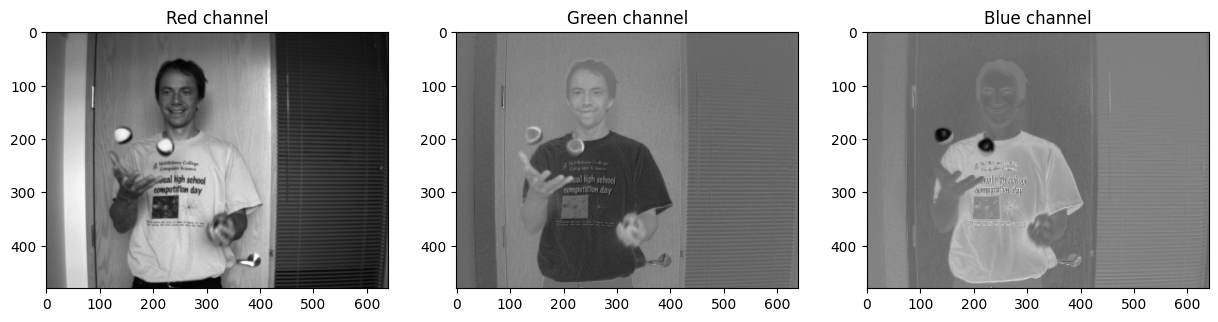

In [42]:
show_channels(img)
show_channels(cv.cvtColor(img, cv.COLOR_RGB2HSV))
show_channels(cv.cvtColor(img, cv.COLOR_RGB2LAB))
show_channels(cv.cvtColor(img, cv.COLOR_RGB2YCrCb))

In [51]:
def show_channels_blurred(img, ksize=3, sigma=3):
    img_R = img[:,:,0]
    img_G = img[:,:,1]
    img_B = img[:,:,2]

    img_R = cv.GaussianBlur(img, (ksize, ksize), sigma)
    img_G = cv.GaussianBlur(img, (ksize, ksize), sigma)
    img_B = cv.GaussianBlur(img, (ksize, ksize), sigma)
    plt.figure(figsize=(15,10))
    plt.subplot(131)
    plt.title("Red channel")
    plt.imshow(img_R, cmap="gray")

    plt.subplot(132)
    plt.title("Green channel")
    plt.imshow(img_G, cmap="gray")

    plt.subplot(133)
    plt.title("Blue channel")
    plt.imshow(img_B, cmap="gray")

    plt.show()

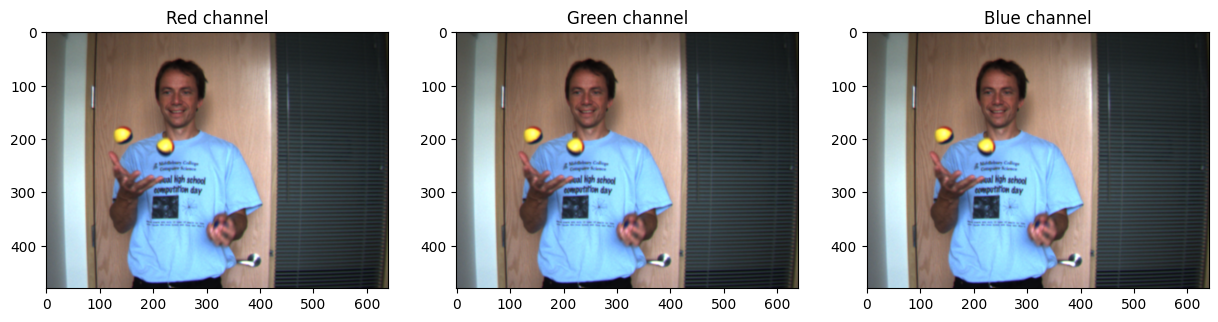

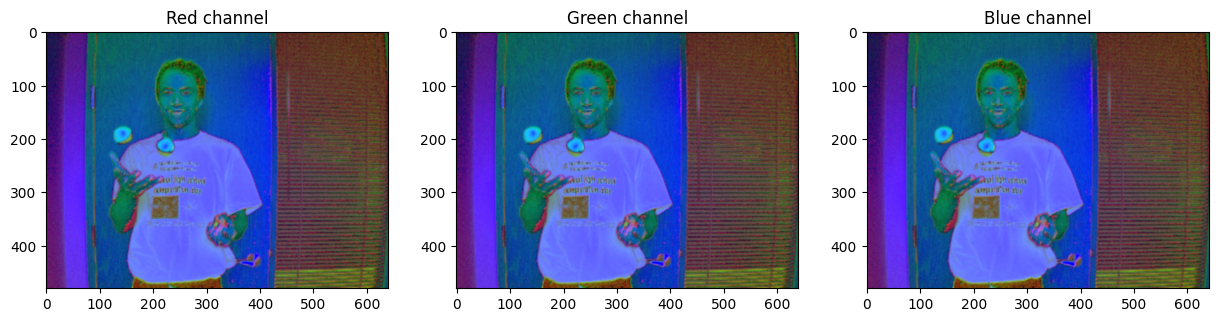

In [52]:
show_channels_blurred(img)
show_channels_blurred(cv.cvtColor(img, cv.COLOR_RGB2HSV))

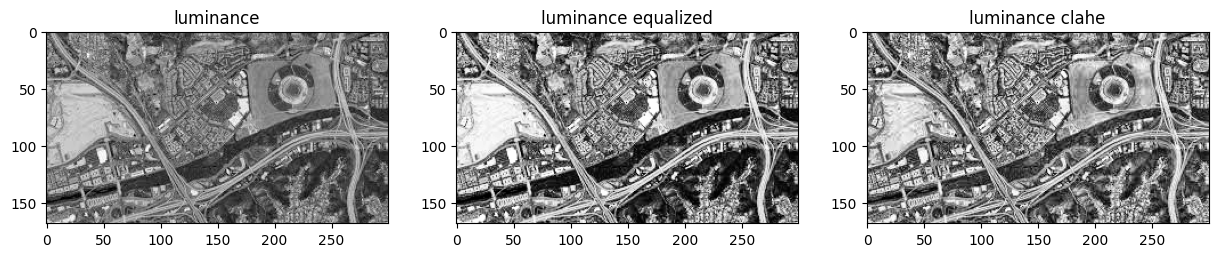

In [135]:
input_dir = Path('./satellite_img.png')
shift_0 = cv.imread(str(input_dir))
img = cv.cvtColor(shift_0, cv.COLOR_BGR2LAB)
img_equalized = cv.equalizeHist(img[:,:,0])
img_clahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(15,15)).apply(img[:,:,0])

plt.figure(figsize=(15,15))
plt.subplot(131)
plt.title("luminance")
plt.imshow(img[:,:,0], cmap="gray")
plt.subplot(132)
plt.title("luminance equalized")
plt.imshow(img_equalized, cmap="gray")
plt.subplot(133)
plt.title("luminance clahe")
plt.imshow(img_clahe, cmap="gray")
plt.show()

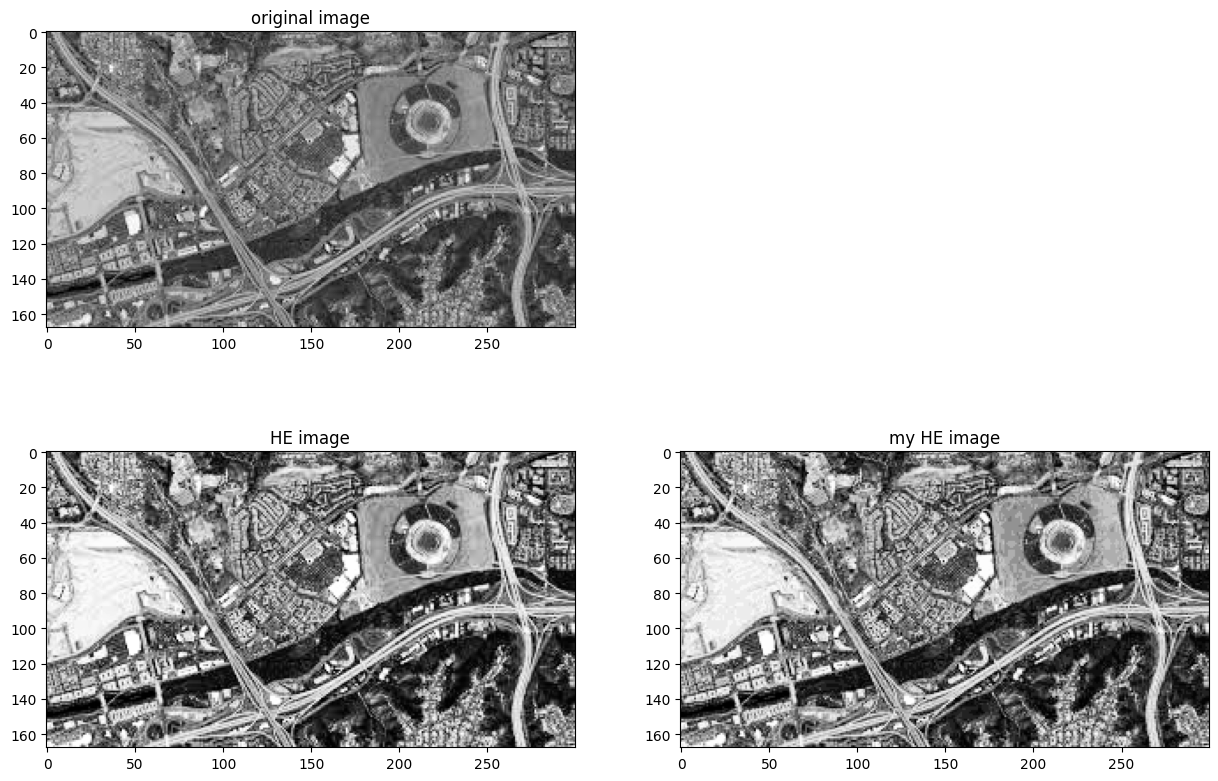

In [158]:
def show_histogram(img, num_bins=20):
    l = img
    counts, bins = np.histogram(l, bins=num_bins, range=(0,255))
    plt.stairs(counts, bins)
    cdf = np.cumsum(counts)
    # plt.plot(bins[:-1], cdf, color='blue') 
    plt.show()

def my_equalize(img, num_bins=20):
    counts, bins = np.histogram(img, bins=num_bins, range=(0,255))
    cfd = np.cumsum(counts)
    bin_edges = np.linspace(0, 255, num_bins)
    # np.digitize returns the indices of the bins to which each value in the input array belongs
    binned_image = np.digitize(img, bins=bin_edges) - 1  # Subtract 1 to get zero-indexed bins
    new_img = np.zeros_like(binned_image, np.uint8)
    for i in range(binned_image.shape[0]):
        for j in range(binned_image.shape[1]):
            bin_index = binned_image[i,j]
            new_img[i,j] = ((cfd[bin_index] - min(cfd))/ (img.shape[0] * img.shape[1] - min(cfd)) * 255)

    return new_img
# show_histogram(img[:,:,0])
# show_histogram(cv.equalizeHist(img[:,:,0]))
# show_histogram(my_equalize(img[:,:,0]))

plt.figure(figsize=(15,10))
plt.subplot(221)
plt.title("original image")
plt.imshow(img[:,:,0], cmap="gray")
plt.subplot(223)
plt.title("HE image")
plt.imshow(cv.equalizeHist(img[:,:,0]), cmap="gray")
plt.subplot(224)
plt.title("my HE image")
plt.imshow(my_equalize(img[:,:,0]), cmap="gray")
plt.show()


[[[1 2 3 4 5]
  [1 2 3 4 5]
  [1 2 3 4 5]]

 [[1 2 3 4 5]
  [1 2 3 4 5]
  [1 2 3 4 5]]

 [[1 2 3 4 5]
  [1 2 3 4 5]
  [1 2 3 4 5]]

 [[1 2 3 4 5]
  [1 2 3 4 5]
  [1 2 3 4 6]]]
[[[0 1 1 2 2]
  [0 1 1 2 2]
  [0 1 1 2 2]]

 [[0 1 1 2 2]
  [0 1 1 2 2]
  [0 1 1 2 2]]

 [[0 1 1 2 2]
  [0 1 1 2 2]
  [0 1 1 2 2]]

 [[0 1 1 2 2]
  [0 1 1 2 2]
  [0 1 1 2 3]]]
